### torch/pyannote環境設定

In [1]:
# === ブロック0: 既存のまま（変更なし） ==============================
import sys, types, torchaudio

def _noop(*a, **k): pass
if not hasattr(torchaudio, "set_audio_backend"):
    torchaudio.set_audio_backend = _noop
if not hasattr(torchaudio, "get_audio_backend"):
    torchaudio.get_audio_backend = lambda: "soundfile"
if not hasattr(torchaudio, "list_audio_backends"):
    torchaudio.list_audio_backends = lambda: ["soundfile"]
torchaudio.set_audio_backend("soundfile")

mod_backend = types.ModuleType("torchaudio.backend")
mod_common  = types.ModuleType("torchaudio.backend.common")
try:
    from torchaudio import AudioMetaData as _AMD
except Exception:
    class _AMD:
        pass
mod_common.AudioMetaData = _AMD
sys.modules["torchaudio.backend"] = mod_backend
sys.modules["torchaudio.backend.common"] = mod_common

import soundfile as sf
if not hasattr(torchaudio, "info"):
    def _info(path):
        try:
            f = sf.SoundFile(path)
            sr = f.samplerate
            frames = len(f)
            channels = f.channels
            f.close()
            class Info:
                sample_rate = sr
                num_channels = channels
                num_frames = frames
            return Info()
        except Exception as e:
            raise RuntimeError(f"torchaudio.info fallback failed for {path}: {e}")
    torchaudio.info = _info

from pyannote.audio import Pipeline
pipe = Pipeline.from_pretrained(
    "pyannote/speaker-diarization-3.1",
    use_auth_token=__import__("os").environ["HF_TOKEN"]
)
# pipe = pipe.to("cuda")
print("pipeline ready ✓")


/root/.venv/pyannote311/lib/python3.11/site-packages/torch/backends/__init__.py:46: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  self.setter(val)
/root/.venv/pyannote311/lib/python3.11/site-packages/pyannote/audio/pipelines/speaker_verification.py:45: UserWarning: Module 'speechbrain.pretrained' was deprecated, redirecting to 'speechbrain.inference'. Please update your script. This is a change from SpeechBrain 1.0. See: https://github.com/speechbrain/speechbrain/releases/tag/v1.0.0
  from speechbrain.p

pipeline ready ✓


### 音声データ属性の整理

In [2]:
# === ブロック1: 共通ユーティリティ =================================
import numpy as np, librosa, soundfile as sf, pyloudnorm as pyln, scipy.signal as sig, matplotlib.pyplot as plt
from pathlib import Path

# FILE_NAME = "20240827/右後_4回目_大野"
BASE_DIR = Path("/root/MedWhisper")
WAV      ="/root/MedWhisper/0606data/8回目_右後ろ.wav" 
WAV = "/root/MedWhisper/20240827/右後_4回目_大野.wav"            # ★ 生波形（Diarizationはこれを使う）
OUTDIR   = Path(f"./_work"); OUTDIR.mkdir(exist_ok=True, parents=True)

def rms_db(x): return 20*np.log10(np.sqrt(np.mean(x**2))+1e-12)
def lufs(x, sr): return pyln.Meter(sr).integrated_loudness(x)
def lufs_norm(x, sr, target=-24.0):
    m = pyln.Meter(sr)
    return np.clip(pyln.normalize.loudness(x, m.integrated_loudness(x), target), -1.0, 1.0)

def rough_vad_mask(x, sr, frame=0.025, hop=0.010):
    frm = int(sr*frame); hopN = int(sr*hop)
    E = librosa.feature.rms(y=x, frame_length=frm, hop_length=hopN).squeeze()
    thr = np.percentile(E, 70) * 0.6
    t = np.arange(len(E))*hop + frame/2
    return t, (E>thr).astype(float), E, float(thr)

def peaking_eq(x, fs, f0=1500.0, Q=1.0, gain_db=3.0):
    A = 10**(gain_db/40.0)
    w0 = 2*np.pi*f0/fs
    alpha = np.sin(w0)/(2.0*Q)
    cw = np.cos(w0)
    b0 = 1 + alpha*A
    b1 = -2*cw
    b2 = 1 - alpha*A
    a0 = 1 + alpha/A
    a1 = -2*cw
    a2 = 1 - alpha/A
    b = np.array([b0, b1, b2]) / a0
    a = np.array([1.0, a1/a0, a2/a0])
    return sig.filtfilt(b, a, x)

print("Block1 ready ✓")


Block1 ready ✓


Block1 ready ✓
sr=16000, dur=193.44s, peak=0.312, RMS(dBFS)=-35.9, LUFS=-37.0


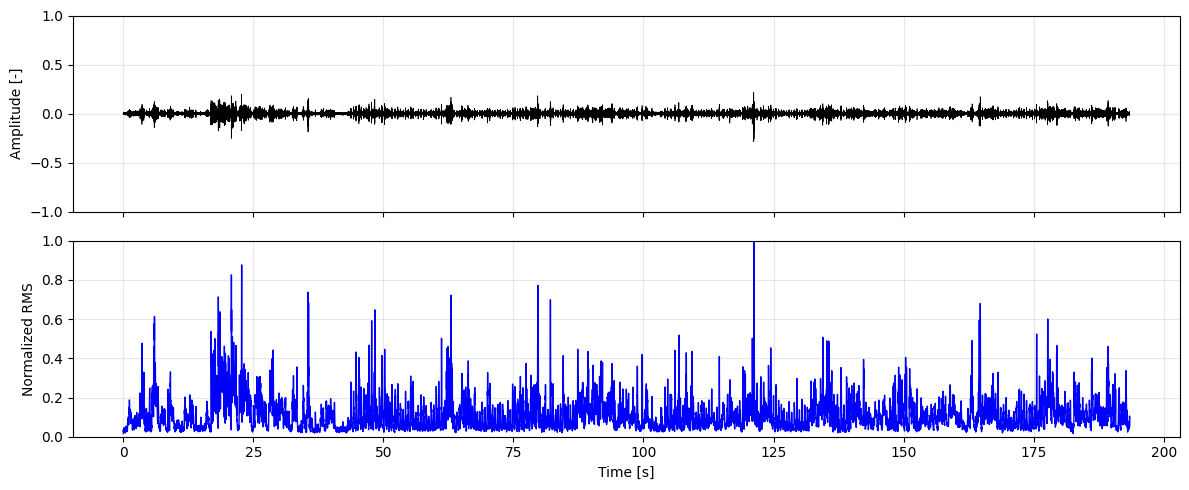

In [3]:
# -*- coding: utf-8 -*-
# === ブロック1: 共通ユーティリティ =================================
import numpy as np, librosa, soundfile as sf, pyloudnorm as pyln, scipy.signal as sig, matplotlib.pyplot as plt
from pathlib import Path


WAV = "/root/MedWhisper/20240827/右後_4回目_大野.wav"
OUTDIR = Path("./_work")                             # 出力は _work 直下
OUTDIR.mkdir(exist_ok=True, parents=True)

# === 基本関数 ===
def rms_db(x): return 20 * np.log10(np.sqrt(np.mean(x**2)) + 1e-12)
def lufs(x, sr): return pyln.Meter(sr).integrated_loudness(x)

def rough_vad_mask(x, sr, frame=0.025, hop=0.010):
    frm = int(sr * frame); hopN = int(sr * hop)
    E = librosa.feature.rms(y=x, frame_length=frm, hop_length=hopN).squeeze()
    thr = np.percentile(E, 70) * 0.6
    t = np.arange(len(E)) * hop + frame / 2
    return t, (E > thr).astype(float), E, float(thr)

print("Block1 ready ✓")

# === ブロック2: 入力診断（デバッグ用） =======================
y, sr = librosa.load(WAV, sr=16000, mono=True)
dur = len(y) / sr
print(f"sr={sr}, dur={dur:.2f}s, peak={np.max(np.abs(y)):.3f}, "
      f"RMS(dBFS)={rms_db(y):.1f}, LUFS={lufs(y,sr):.1f}")

t_mask, mask, E, thr = rough_vad_mask(y, sr)

max_pts = 200_000
step = max(1, len(y) // max_pts)
y_plot = y[::step]
t_plot = np.arange(len(y_plot)) * step / sr

# === 可視化（波形＋RMSのみ） ===
fig, ax = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

# 上段：生波形
ax[0].plot(t_plot, y_plot, lw=0.5, color="black")
ax[0].set_ylabel("Amplitude [-]")
ax[0].set_ylim(-1,1)
ax[0].grid(True, alpha=0.3)

# 下段：RMSのみ
E_scaled = E / (E.max() + 1e-12)
ax[1].plot(t_mask, E_scaled, lw=1.0, color="blue", label="RMS (scaled)")
ax[1].set_xlabel("Time [s]")
ax[1].set_ylabel("Normalized RMS")
ax[1].set_ylim(0, 1)
ax[1].grid(True, alpha=0.3)
# ax[1].legend(loc="upper right")

plt.tight_layout()
plt.show()


### 資料用グラフ

In [ ]:
# # -*- coding: utf-8 -*-
# # ① 4つのWAVから“個別グラフ”を作成 → ② その4枚画像を2x2に合成
# import numpy as np
# import soundfile as sf
# import librosa
# import matplotlib.pyplot as plt
# from pathlib import Path
# from PIL import Image

# # ===== 入力WAV（順序固定：1,2 / 3,4） =====
# wav_list = [
#     "/root/MedWhisper/20240827/右後_4回目_大野.wav",      # 1
#     "/root/MedWhisper/20241018/右後_2回目_川村先生.wav",  # 2
#     "/root/MedWhisper/0604data/1回目_右後ろ.wav",        # 3
#     "/root/MedWhisper/0604data/2回目_右後ろ.wav",        # 4
# ]

# OUTDIR = Path("./_work"); OUTDIR.mkdir(parents=True, exist_ok=True)

# # ===== ユーティリティ =====
# def rough_rms_series(x, sr, frame=0.025, hop=0.010):
#     """RMS時系列（librosa RMS）とその時間軸を返す"""
#     frm = int(sr*frame); hopN = int(sr*hop)
#     E = librosa.feature.rms(y=x, frame_length=frm, hop_length=hopN).squeeze()
#     t = np.arange(len(E))*hop + frame/2
#     return t, E

# def make_single_plot(wav_path: str, out_png: Path, max_pts: int = 200_000):
#     """上段：非正規化PCM波形（黒, ylimなし, タイトルなし）
#        下段：正規化RMS（青, 0..1, タイトルなし）
#        を1枚の画像として保存する。
#     """
#     # --- 非正規化で読み込み（int16のまま）
#     y_raw, sr = sf.read(wav_path, dtype='int16', always_2d=False)
#     if y_raw.ndim == 2:  # ステレオ→モノラル平均
#         y_raw = y_raw.mean(axis=1).astype('int16')

#     # --- 解析用に float(-1..1) に変換
#     y = y_raw.astype('float32') / 32768.0

#     # --- RMS系列
#     t_rms, E = rough_rms_series(y, sr)
#     E_scaled = E / (E.max() + 1e-12)

#     # --- 上段プロットの間引き
#     step = max(1, len(y_raw)//max_pts)
#     y_plot = y_raw[::step]
#     t_plot = np.arange(len(y_plot)) * step / sr

#     # --- 図を作成（上下2段、タイトルは無し）
#     fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

#     # 上段：非正規化PCM（int16）
#     ax_top.plot(t_plot, y_plot, lw=0.5, color="black")
#     ax_top.set_ylabel("Amplitude [PCM int16]", fontsize=14)
#     ax_top.grid(True, alpha=0.3)
#     # タイトルは付けない
#     # x目盛ラベルは下段にのみ表示
#     plt.setp(ax_top.get_xticklabels(), visible=False)

#     # 下段：正規化RMS
#     ax_bot.plot(t_rms, E_scaled, lw=1.0, color="blue")
#     ax_bot.set_xlabel("Time [s]", fontsize=14)
#     ax_bot.set_ylabel("Normalized RMS", fontsize=14)
#     ax_bot.set_ylim(0, 1)
#     ax_bot.grid(True, alpha=0.3)

#     plt.tight_layout()
#     fig.savefig(out_png, dpi=150)
#     plt.close(fig)

# # ===== ① 個別グラフを4枚作る =====
# png_list = []
# for i, wav in enumerate(wav_list, start=1):
#     out_png = OUTDIR / f"wav_plot_{i:02d}.png"
#     make_single_plot(wav, out_png)
#     png_list.append(out_png)
#     print(f"saved: {out_png}")

# # ===== ② 4枚のPNGを2×2に合成（1 2 / 3 4） =====
# # すべて同じサイズで出力されているはずだが、念のため先頭サイズにリサイズして整える
# imgs = [Image.open(p).convert("RGB") for p in png_list]
# base_w, base_h = imgs[0].size
# imgs = [im.resize((base_w, base_h), Image.BICUBIC) for im in imgs]

# canvas = Image.new("RGB", (base_w*2, base_h*2), (255, 255, 255))
# # 配置：1,2 / 3,4
# canvas.paste(imgs[0], (0,        0))
# canvas.paste(imgs[1], (base_w,   0))
# canvas.paste(imgs[2], (0,      base_h))
# canvas.paste(imgs[3], (base_w, base_h))

# final_path = OUTDIR / "collage_2x2_from_wavs.png"
# canvas.save(final_path, quality=95)
# print(f"saved collage: {final_path}")


sr=44100, dur=193.44s, peak(norm)=0.312, RMS(dBFS)=-35.9, LUFS=-37.0


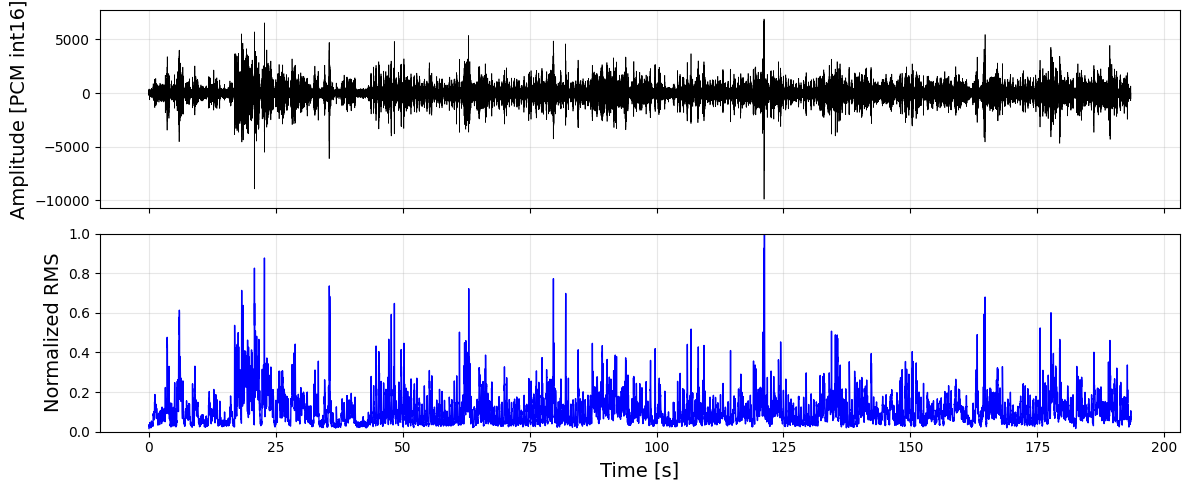

In [4]:
# === 置き換え：読み込み〜可視化（上段は非正規化・下段は従来通りRMS） ===
import soundfile as sf
# === パス設定（シンプル構成） ===
WAV = "/root/MedWhisper/20240827/右後_4回目_大野.wav"
  # ★ WAVファイルの絶対パス
# 1) 非正規化で読み込み（int16のまま）
y_raw, sr = sf.read(WAV, dtype='int16', always_2d=False)  # y_raw: int16, -32768..32767
if y_raw.ndim == 2:  # ステレオならモノラル化（平均）
    y_raw = y_raw.mean(axis=1).astype('int16')

# 2) 解析用に float へ変換（-1..1 にスケール）
y = y_raw.astype('float32') / 32768.0

# 3) 以降は従来処理（RMSなど）
dur = len(y) / sr
print(f"sr={sr}, dur={dur:.2f}s, peak(norm)={float(np.max(np.abs(y))):.3f}, RMS(dBFS)={rms_db(y):.1f}, LUFS={lufs(y,sr):.1f}")

t_mask, mask, E, thr = rough_vad_mask(y, sr)
max_pts = 200_000
step = max(1, len(y_raw) // max_pts)  # 上段は y_raw ベースで間引き
y_plot = y_raw[::step]
t_plot = np.arange(len(y_plot)) * step / sr

# 4) 可視化
fig, ax = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

# 上段：非正規化の生PCM波形（ylim設定なし）
ax[0].plot(t_plot, y_plot, lw=0.5, color="black")
ax[0].set_ylabel("Amplitude [PCM int16]", fontsize=14)  # -32768..32767 相当
ax[0].grid(True, alpha=0.3)

# 下段：RMSのみ（正規化表示）
E_scaled = E / (E.max() + 1e-12)
ax[1].plot(t_mask, E_scaled, lw=1.0, color="blue", label="RMS (scaled)")
ax[1].set_xlabel("Time [s]", fontsize=14)
ax[1].set_ylabel("Normalized RMS", fontsize=14)
ax[1].set_ylim(0, 1)
ax[1].grid(True, alpha=0.3)
# ax[1].legend(loc="upper right")

plt.tight_layout()
plt.show()


### 加工

[ASR-pre] HPF=80Hz, LPF=8000Hz, Peak 1500.0Hz +3.0dB
RMS(dBFS)=-36.1, LUFS=-36.2, peak=0.280


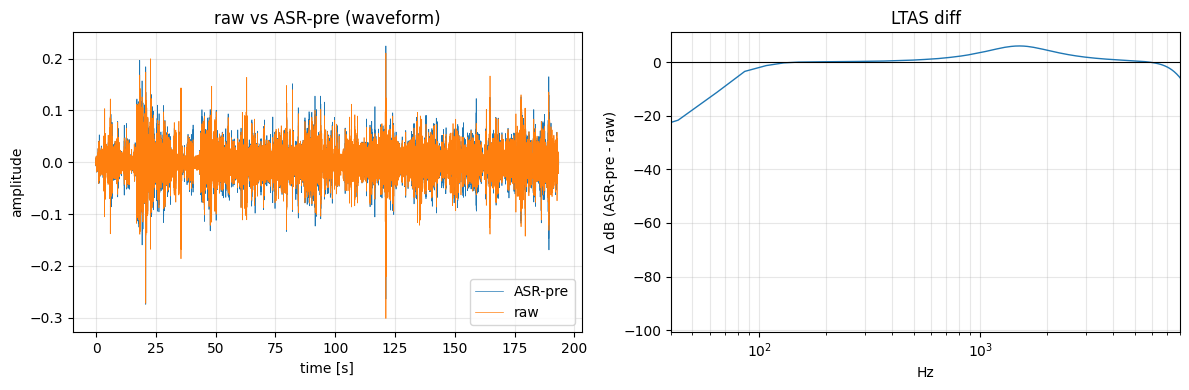

In [5]:
# === ブロック4: ASR用の帯域整形（Diarizationとは分離） ==============
# ★ Diarizationは生WAVを使う。ここはASR前処理用の参考出力。
HPF_HZ   = 80
LPF_HZ   = 8000
PEAK_F0  = 1500.0
PEAK_Q   = 1.0
PEAK_DB  = 3.0

xB = y.copy()
nyq = sr / 2
LPF_SAFE = min(LPF_HZ, 0.95 * nyq)

sos = sig.butter(4, HPF_HZ, btype="highpass", fs=sr, output="sos"); xB = sig.sosfiltfilt(sos, xB)
sos = sig.butter(4, LPF_SAFE, btype="lowpass",  fs=sr, output="sos"); xB = sig.sosfiltfilt(sos, xB)
xB = peaking_eq(xB, fs=sr, f0=PEAK_F0, Q=PEAK_Q, gain_db=PEAK_DB)
xB = np.clip(xB, -1, 1)

FILE_NAME = "_work"
asr_out = OUTDIR / f"asr大野ver003_{FILE_NAME}.wav"
asr_out.parent.mkdir(parents=True, exist_ok=True)
sf.write(asr_out.as_posix(), xB, sr)
print(f"[ASR-pre] HPF={HPF_HZ}Hz, LPF={int(LPF_SAFE)}Hz, Peak {PEAK_F0}Hz +{PEAK_DB}dB")
print(f"RMS(dBFS)={rms_db(xB):.1f}, LUFS={lufs(xB,sr):.1f}, peak={np.max(np.abs(xB)):.3f}")

# （参考の可視化）
def ltas_db(x, sr, n_fft=2048, hop=512):
    S = np.abs(librosa.stft(x, n_fft=n_fft, hop_length=hop)).mean(axis=1)
    f = librosa.fft_frequencies(sr=sr, n_fft=n_fft)
    return f, 20*np.log10(S + 1e-12)

max_pts = 200_000
stepA = max(1, len(y)  // max_pts); stepB = max(1, len(xB) // max_pts)
tA = np.arange(0, len(y),  stepA) / sr; y_d = y[ ::stepA]
tB = np.arange(0, len(xB), stepB) / sr; b_d = xB[::stepB]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(tB, b_d, lw=0.5, label="ASR-pre")
axes[0].plot(tA, y_d, lw=0.5, label="raw")
axes[0].set_title("raw vs ASR-pre (waveform)"); axes[0].set_xlabel("time [s]"); axes[0].set_ylabel("amplitude")
axes[0].grid(True, alpha=0.3); axes[0].legend()

fA, dA = ltas_db(y,  sr); fB, dB = ltas_db(xB, sr)
dA_i = np.interp(fB, fA, dA)
axes[1].semilogx(fB, dB - dA_i, lw=1.0)
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_xlim(40, 8000)
axes[1].set_ylabel("Δ dB (ASR-pre - raw)"); axes[1].set_xlabel("Hz")
axes[1].set_title("LTAS diff")
axes[1].grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()


In [ ]:
# # -*- coding: utf-8 -*-
# # LTAS（long-term average spectrum）と差分を同一条件で可視化
# # 左：raw vs processed（dB）/ 右：ΔdB（processed - raw）
# #
# # 使い方：
# #   1) PAIRS に (raw, processed, 出力PNG) を列挙
# #   2) 実行すると各ペアごとに PNG を保存

# import numpy as np
# import librosa
# import matplotlib.pyplot as plt
# from pathlib import Path

# # ========= ① 入力WAVのペア一覧 =========
# # 例：
# PAIRS = [
#     ("/root/MedWhisper/0604data/1回目_右前.wav",
#      "/root/MedWhisper/_work/asr右前1回目__work.wav",
#      "./outputs/diarization/cmp_ltas_only.png"),
#     # 追加したい場合は以下のように追記
#     # ("/path/to/raw.wav", "/path/to/processed.wav", "./out/cmp_raw_proc.png"),
# ]

# # ========= ② 可視化条件（全案件で固定） =========
# SR = 16000          # 強制リサンプル（Whisper標準に合わせる）
# N_FFT = 4096
# HOP = 1024
# FMIN = 40           # 周波数軸の下限（プロット用）
# FMAX = 8000         # 周波数軸の上限（プロット用）
# YMIN_DIFF = -60     # 右図（ΔdB）のy軸下限
# YMAX_DIFF = 10      # 右図（ΔdB）のy軸上限

# # （見栄え）
# LABEL_SIZE = 16
# TICK_SIZE  = 14
# LEGEND_SIZE = 14
# FIGSIZE = (14, 4.5)

# # ========= ③ 関数群 =========
# def load_mono(path: str, sr: int = SR):
#     """monoで読み込み（必要ならリサンプル）"""
#     y, sr_out = librosa.load(path, sr=sr, mono=True)
#     return y.astype(np.float32), sr

# def ltas_db(y: np.ndarray, sr: int, n_fft: int = N_FFT, hop: int = HOP):
#     """LTAS（|STFT|の周波数方向平均）→ dB"""
#     S = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop))
#     mag_mean = S.mean(axis=1)
#     f = librosa.fft_frequencies(sr=sr, n_fft=n_fft)
#     db = 20.0 * np.log10(mag_mean + 1e-12)
#     return f, db

# def plot_ltas_pair(raw_wav: str, proc_wav: str, out_png: str):
#     # 1) 読み込み
#     raw, sr = load_mono(raw_wav, SR)
#     proc, _ = load_mono(proc_wav, SR)

#     # 2) 長さを合わせる（安全のため短い方に揃える）
#     N = min(len(raw), len(proc))
#     raw = raw[:N]
#     proc = proc[:N]

#     # 3) LTAS（同一パラメータ）
#     f_raw,  d_raw  = ltas_db(raw,  sr, N_FFT, HOP)
#     f_proc, d_proc = ltas_db(proc, sr, N_FFT, HOP)

#     # 4) 周波数軸を一致させて差分（processed - raw）
#     d_raw_i = np.interp(f_proc, f_raw, d_raw)
#     d_diff  = d_proc - d_raw_i

#     # 5) 図
#     Path(out_png).parent.mkdir(parents=True, exist_ok=True)
#     plt.figure(figsize=FIGSIZE)

#     # 左：LTAS
#     ax1 = plt.subplot(1, 2, 1)
#     ax1.semilogx(f_proc, d_raw_i,  label="raw",       linewidth=1.2, color="blue")
#     ax1.semilogx(f_proc, d_proc,   label="processed", linewidth=1.2, color="red")
#     ax1.set_xlim(FMIN, FMAX)
#     ax1.set_xlabel("Frequency (Hz)", fontsize=LABEL_SIZE)
#     ax1.set_ylabel("dB", fontsize=LABEL_SIZE)
#     ax1.grid(True, which="both", alpha=0.3)
#     ax1.legend(fontsize=LEGEND_SIZE)
#     ax1.tick_params(axis='both', which='both', labelsize=TICK_SIZE)

#     # 右：ΔLTAS
#     ax2 = plt.subplot(1, 2, 2)
#     ax2.semilogx(f_proc, d_diff, linewidth=1.5, color="green")
#     ax2.set_xlim(FMIN, FMAX)
#     ax2.set_ylim(YMIN_DIFF, YMAX_DIFF)
#     ax2.set_xlabel("Frequency (Hz)", fontsize=LABEL_SIZE)
#     ax2.set_ylabel("ΔdB (proc - raw)", fontsize=LABEL_SIZE)
#     ax2.grid(True, which="both", alpha=0.3)
#     ax2.tick_params(axis='both', which='both', labelsize=TICK_SIZE)

#     # 0 dB線を太線で
#     ax2.axhline(0, linewidth=2.5, linestyle='-', color='black', alpha=0.9, zorder=0)

#     plt.tight_layout()
#     plt.savefig(out_png, dpi=150)
#     plt.close()
#     print(f"[Saved] {out_png}")

# # ========= ④ 実行 =========
# if __name__ == "__main__":
#     for raw, proc, out_png in PAIRS:
#         plot_ltas_pair(raw, proc, out_png)


### 比較するRMS

In [ ]:
# -*- coding: utf-8 -*-
# 生WAV vs 処理済WAV の時系列RMS比較（同一条件で可視化）
# 上：RMS[dBFS] の推移（raw=青, proc=赤）
# 下：ΔRMS[dB] = proc - raw の推移（正なら処理で相対的に大きい）

import numpy as np
import librosa
import matplotlib.pyplot as plt

# ====== 入力パス（指定の2本） ======
RAW_WAV  = "/root/MedWhisper/20240827/右後_4回目_大野.wav"
PROC_WAV = "/root/MedWhisper/_work/asr大野ver003__work.wav"

# ====== 共通パラメータ ======
SR        = 16000       # Whisper想定に合わせて統一
FRAME_SEC = 0.025       # 25 ms
HOP_SEC   = 0.010       # 10 ms

# ====== 便利関数 ======
def rms_db(x: np.ndarray) -> float:
    return 20*np.log10(np.sqrt(np.mean(x**2)) + 1e-12)

def frame_rms(x: np.ndarray, sr: int, frame_s: float, hop_s: float):
    frm  = int(sr*frame_s)
    hop  = int(sr*hop_s)
    E    = librosa.feature.rms(y=x, frame_length=frm, hop_length=hop).squeeze()  # 线形RMS
    t    = np.arange(len(E))*hop/sr + frame_s/2
    E_db = 20*np.log10(E + 1e-12)  # dBFS（フルスケール=1基準）
    return t, E, E_db

# ====== 読み込み（mono, SR統一） ======
y_raw,  _ = librosa.load(RAW_WAV,  sr=SR, mono=True)
y_proc, _ = librosa.load(PROC_WAV, sr=SR, mono=True)

# 長さは短い方にそろえる（安全）
N = min(len(y_raw), len(y_proc))
y_raw  = y_raw[:N]
y_proc = y_proc[:N]

# ====== 時系列RMS算出（同条件） ======
t_raw,  Er_raw,  EdB_raw  = frame_rms(y_raw,  SR, FRAME_SEC, HOP_SEC)
t_proc, Er_proc, EdB_proc = frame_rms(y_proc, SR, FRAME_SEC, HOP_SEC)

# フレーム数を揃える（端の1フレーム差を避ける保険）
M = min(len(EdB_raw), len(EdB_proc))
t     = t_raw[:M]
EdB_r = EdB_raw[:M]
EdB_p = EdB_proc[:M]

# 差分（処理後 - 生）
EdB_diff = EdB_p - EdB_r

# ====== 参考メトリクス出力 ======
print(f"[RAW ] dur={len(y_raw)/SR:.2f}s, RMS(dBFS)={rms_db(y_raw):.1f}")
print(f"[PROC] dur={len(y_proc)/SR:.2f}s, RMS(dBFS)={rms_db(y_proc):.1f}")

# ====== 可視化 ======
TITLE_SIZE = 18
LABEL_SIZE = 16
TICK_SIZE  = 13
LEGEND_SIZE= 13

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

# 上：RMS[dBFS]の推移
axes[0].plot(t, EdB_r, lw=1.0, label="RAW (RMS dBFS)",  color="blue")
axes[0].plot(t, EdB_p, lw=1.0, label="PROC (RMS dBFS)", color="red")
axes[0].set_ylabel("RMS [dBFS]", fontsize=LABEL_SIZE)
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="upper right", fontsize=LEGEND_SIZE)

# 下：差分（処理後 − 生）※正→処理の方が相対的に強い
axes[1].plot(t, EdB_diff, lw=1.0, color="green")
axes[1].axhline(0, color="black", lw=1.2)
axes[1].set_xlabel("Time [s]", fontsize=LABEL_SIZE)
axes[1].set_ylabel("ΔRMS [dB]\n(proc - raw)", fontsize=LABEL_SIZE)
axes[1].grid(True, which="both", alpha=0.3)

for ax in axes:
    ax.tick_params(axis='both', which='both', labelsize=TICK_SIZE)

plt.tight_layout()
plt.show()


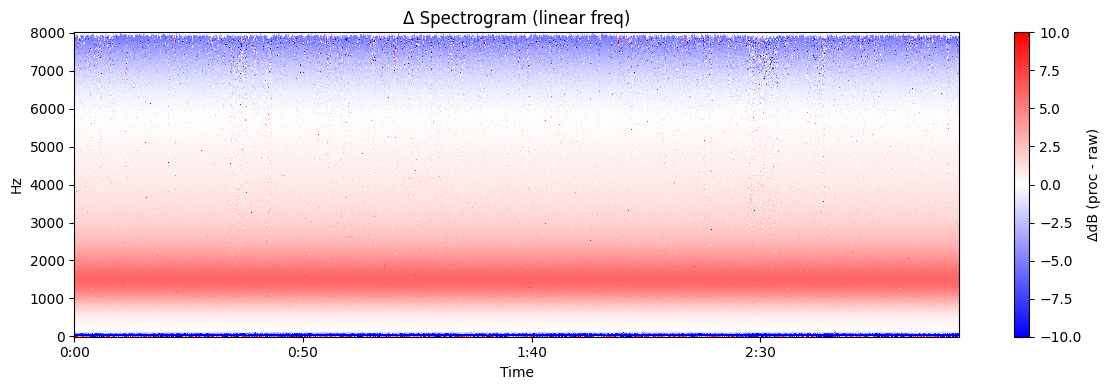

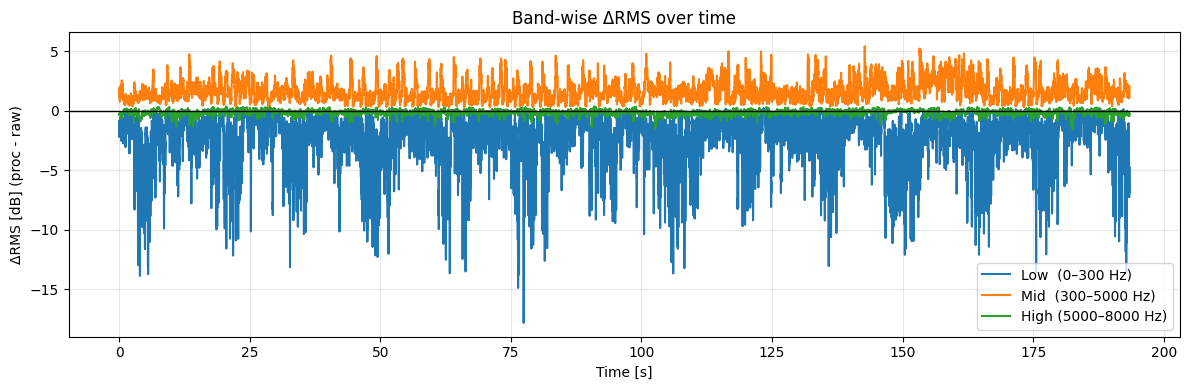

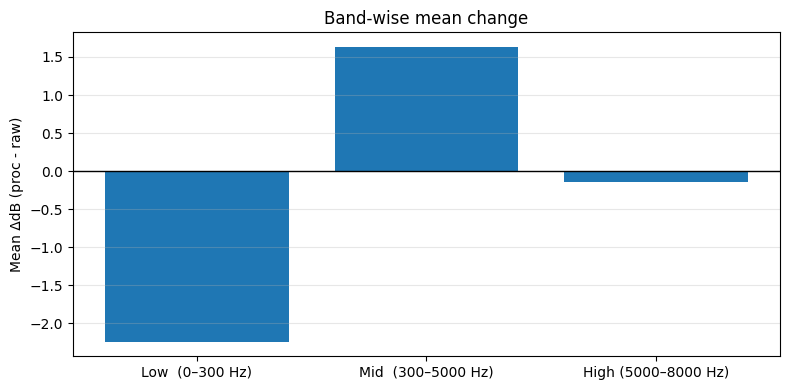

In [6]:
# -*- coding: utf-8 -*-
# 生WAVと処理済WAVの「帯域別」比較（定量）
# 1) Δスペクトログラム (proc - raw) [dB]
# 2) 帯域別ΔRMSの時系列
# 3) 帯域別の平均ΔdB（棒グラフ）

import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

# ===== 入力 =====
RAW_WAV  = "/root/MedWhisper/20240827/右後_4回目_大野.wav"
PROC_WAV = "/root/MedWhisper/_work/asr大野ver003__work.wav"

# ===== パラメータ（Whisperを意識してSR=16k）=====
SR = 16000
N_FFT = 1024               # 時間解像度を保ちつつ帯域も見える程度
HOP   = 160                # 10 ms hop
WINDOW = "hann"
EPS = 1e-12

# 帯域定義（Hz）— 必要に応じて調整
BANDS = {
    "Low  (0–300 Hz)":      (0,   300),
    "Mid  (300–5000 Hz)":   (300, 5000),
    "High (5000–8000 Hz)":  (5000, 8000),
}

# ===== 便利関数 =====
def stft_power(y, sr, n_fft=N_FFT, hop=HOP, window=WINDOW):
    """STFT→電力スペクトル（|S|^2）。S: shape (freq_bins, frames)"""
    S = librosa.stft(y, n_fft=n_fft, hop_length=hop, window=window, center=True)
    P = np.abs(S)**2
    f = librosa.fft_frequencies(sr=sr, n_fft=n_fft)   # 周波数軸 [Hz]
    t = librosa.frames_to_time(np.arange(P.shape[1]), sr=sr, hop_length=hop)
    return P, f, t

def band_mask(f, lo, hi):
    """周波数インデックスのマスク"""
    return (f >= lo) & (f < hi)

def band_rms_db_over_time(P, f, lo, hi):
    """帯域内の電力をフレームごとに平均→RMS[dB]に変換"""
    msk = band_mask(f, lo, hi)
    if not np.any(msk):
        return None
    band_power_t = P[msk, :].mean(axis=0)                 # 各フレームの帯域平均パワー
    band_db_t = 10.0 * np.log10(band_power_t + EPS)       # dB換算
    return band_db_t

# ===== 読み込み（モノラル＋SR統一）=====
y_raw,  _ = librosa.load(RAW_WAV,  sr=SR, mono=True)
y_proc, _ = librosa.load(PROC_WAV, sr=SR, mono=True)
N = min(len(y_raw), len(y_proc))
y_raw  = y_raw[:N]
y_proc = y_proc[:N]

# ===== STFT（同条件）=====
P_raw,  f, t = stft_power(y_raw,  SR)
P_proc, _, _ = stft_power(y_proc, SR)

# ===== 1) Δスペクトログラム（proc - raw）=====
# dBにして差分（メルではなくリニア周波数）
Sdb_raw  = 10.0 * np.log10(P_raw  + EPS)
Sdb_proc = 10.0 * np.log10(P_proc + EPS)
Sdb_diff = Sdb_proc - Sdb_raw     # ΔdB

plt.figure(figsize=(12, 4))
# 上限8kHzまでを見せる
f_max = 8000.0
imax = np.searchsorted(f, f_max, side='right')
librosa.display.specshow(Sdb_diff[:imax, :], x_axis='time', y_axis='linear',
                         sr=SR, hop_length=HOP, cmap='bwr', fmax=f_max, vmin=-10, vmax=+10)
plt.colorbar(label="ΔdB (proc - raw)")
plt.title("Δ Spectrogram (linear freq)")
plt.tight_layout()
plt.show()

# ===== 2) 帯域別ΔRMSの時系列 =====
plt.figure(figsize=(12, 4))
for label, (lo, hi) in BANDS.items():
    db_raw_t  = band_rms_db_over_time(P_raw,  f, lo, hi)
    db_proc_t = band_rms_db_over_time(P_proc, f, lo, hi)
    if db_raw_t is None or db_proc_t is None:
        continue
    # ΔdB = proc - raw
    d_db_t = db_proc_t - db_raw_t
    plt.plot(t, d_db_t, label=f"{label}")

plt.axhline(0, color='k', linewidth=1.0)
plt.xlabel("Time [s]")
plt.ylabel("ΔRMS [dB] (proc - raw)")
plt.title("Band-wise ΔRMS over time")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ===== 3) 帯域別の平均ΔdB（棒グラフ）=====
means = []
labels = []
for label, (lo, hi) in BANDS.items():
    db_raw_t  = band_rms_db_over_time(P_raw,  f, lo, hi)
    db_proc_t = band_rms_db_over_time(P_proc, f, lo, hi)
    if db_raw_t is None or db_proc_t is None:
        continue
    means.append(float(np.mean(db_proc_t - db_raw_t)))
    labels.append(label)

plt.figure(figsize=(8, 4))
x = np.arange(len(means))
plt.bar(x, means)
plt.axhline(0, color='k', linewidth=1.0)
plt.xticks(x, labels, rotation=0)
plt.ylabel("Mean ΔdB (proc - raw)")
plt.title("Band-wise mean change")
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


#### 生波形にpyanotte

In [10]:
# === ブロック5: Diarization（生WAVを使用） ===
from collections import defaultdict

WAV = Path("/root/MedWhisper/_work/asr大野ver003__work.wav").expanduser().resolve()
wav_for_diar = WAV.as_posix()  
dia = pipe(wav_for_diar, min_speakers=2, max_speakers=3)

segments = []  # [(speaker, start, end)]
for turn, _, speaker in dia.itertracks(yield_label=True):
    segments.append((speaker, float(turn.start), float(turn.end)))

dur_by_spk = defaultdict(float)
for spk, s, e in segments:
    dur_by_spk[spk] += (e - s)

print("speakers:", list(dur_by_spk.keys()))
print("durations:", dict(dur_by_spk))
print("segments (head):", segments[:8])


speakers: ['SPEAKER_01', 'SPEAKER_02', 'SPEAKER_00']
durations: {'SPEAKER_01': 34.668930390492385, 'SPEAKER_02': 77.1137521222411, 'SPEAKER_00': 41.91850594227495}
segments (head): [('SPEAKER_01', 0.500848896434635, 4.422750424448218), ('SPEAKER_01', 5.797962648556876, 14.252971137521223), ('SPEAKER_01', 15.71307300509338, 33.845500848896435), ('SPEAKER_01', 34.354838709677416, 35.0), ('SPEAKER_01', 37.78438030560272, 39.00679117147708), ('SPEAKER_02', 39.00679117147708, 39.73684210526316), ('SPEAKER_02', 40.144312393887944, 40.16129032258065), ('SPEAKER_02', 40.178268251273344, 40.85738539898132)]


In [11]:
# === ブロック6: 後処理（連結・除外・パディング）→ 話者別に書き出し ===
from itertools import groupby

def merge_close_segments(seg_list, max_gap=0.4, min_keep=0.6):
    seg_list = sorted(seg_list, key=lambda x: (x[0], x[1], x[2]))
    merged = []
    for spk, group in groupby(seg_list, key=lambda x: x[0]):
        group = list(group)
        cur_s, cur_e = group[0][1], group[0][2]
        for _, s, e in group[1:]:
            if s - cur_e <= max_gap:
                cur_e = max(cur_e, e)
            else:
                if (cur_e - cur_s) >= min_keep:
                    merged.append((spk, cur_s, cur_e))
                cur_s, cur_e = s, e
        if (cur_e - cur_s) >= min_keep:
            merged.append((spk, cur_s, cur_e))
    merged.sort(key=lambda x: x[1])
    return merged

def pad_segments(seg_list, pad=0.2, total_dur=None):
    out = []
    for spk, s, e in seg_list:
        s2 = max(0.0, s - pad)
        e2 = e + pad if total_dur is None else min(total_dur, e + pad)
        out.append((spk, s2, e2))
    return out

segments_merged = merge_close_segments(segments, max_gap=0.4, min_keep=0.6)
total_dur = librosa.get_duration(path=wav_for_diar)
segments_padded = pad_segments(segments_merged, pad=0.2, total_dur=total_dur)
print(f"segments: raw={len(segments)}, merged={len(segments_merged)}, padded={len(segments_padded)}")

y_base, sr_base = librosa.load(wav_for_diar, sr=None, mono=True)
print(f"base audio: sr={sr_base}, dur={len(y_base)/sr_base:.2f}s")

buckets = defaultdict(list)
for spk, s, e in segments_padded:
    buckets[spk].append((s, e))

# ★ 保存ディレクトリを raw_spk_ に変更
for spk, spans in buckets.items():
    spkdir = OUTDIR / f"大野ver003_spk_{spk}"
    spkdir.mkdir(exist_ok=True)
    count = 0
    for i, (s, e) in enumerate(spans):
        s0, s1 = int(s * sr_base), int(e * sr_base)
        if s1 > s0:
            seg = y_base[s0:s1]
            out_path = spkdir / f"{i:02d}_{spk}_{s:.2f}-{e:.2f}.wav"
            sf.write(out_path.as_posix(), seg, sr_base)
            count += 1
    print(f"{spk}: saved {count} segments in {spkdir}")


segments: raw=43, merged=18, padded=18
base audio: sr=44100, dur=193.44s


SPEAKER_01: saved 7 segments in _work/大野ver003_spk_SPEAKER_01
SPEAKER_02: saved 7 segments in _work/大野ver003_spk_SPEAKER_02
SPEAKER_00: saved 4 segments in _work/大野ver003_spk_SPEAKER_00


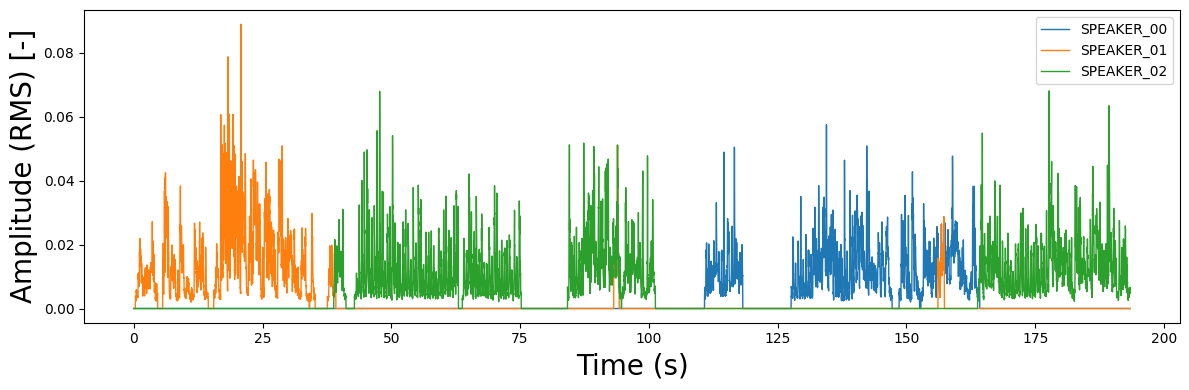

In [12]:
# === ブロック7: 時系列グラフ（話者別RMS） ============================
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
from collections import defaultdict

y_plot, sr_plot = sf.read(wav_for_diar, always_2d=False)
if y_plot.ndim > 1: y_plot = y_plot.mean(axis=1)

hop = int(0.01 * sr_plot)
win = int(0.032 * sr_plot)
num = max(1, 1 + (len(y_plot) - win) // hop)
pad = max(0, win + (num - 1) * hop - len(y_plot))
if pad > 0: y_plot = np.concatenate([y_plot, np.zeros(pad)], axis=0)

rms = np.array([np.sqrt(np.mean(y_plot[i*hop:i*hop+win]**2)) for i in range(num)])
times = (np.arange(num) * hop + win/2) / sr_plot

buckets = defaultdict(list)
for spk, s, e in segments_padded:
    buckets[spk].append((s, e))

plt.figure(figsize=(12, 4))
for spk, spans in sorted(buckets.items()):
    arr = np.zeros_like(rms)
    for s, e in spans:
        mask = (times >= s) & (times < e)
        arr[mask] = rms[mask]
    plt.plot(times, arr, label=spk, linewidth=1.0)



plt.xlabel("Time (s)", fontsize=20)
plt.ylabel("Amplitude (RMS) [-]",fontsize=20)

plt.legend()
plt.tight_layout()
plt.show()

#### 加工済wavにpyanoote

In [ ]:
# === ブロック5: Diarization（生WAVを使用） ===========================
from collections import defaultdict

FILE_NAME = "_work"
RE_WAV = OUTDIR / f"asr大野ver002_{FILE_NAME}.wav"

wav_for_diar = RE_WAV.as_posix()  # ★ 生波形
dia = pipe(wav_for_diar, min_speakers=2, max_speakers=3)

segments = []  # [(speaker, start, end)]
for turn, _, speaker in dia.itertracks(yield_label=True):
    segments.append((speaker, float(turn.start), float(turn.end)))

dur_by_spk = defaultdict(float)
for spk, s, e in segments:
    dur_by_spk[spk] += (e - s)

print("speakers:", list(dur_by_spk.keys()))
print("durations:", dict(dur_by_spk))
print("segments (head):", segments[:8])

In [13]:
# === ブロック5+6: Diarization（しきい緩和 + 事後マージ強化） =================
from collections import defaultdict
from itertools import groupby
import librosa, soundfile as sf
from pathlib import Path

RE_WAV = OUTDIR / f"asr1_{FILE_NAME}.wav"
wav_for_diar ="/root/MedWhisper/_work/asr大野ver003__work.wav"# RE_WAV.as_posix()

# --- ① pyannote内部の二値化/最小継続時間を緩める（可能な場合） ---
# ・短い息継ぎで切れないよう min_duration_on/off を長めに
# ・ヒステリシス（onset/offset）で境界を安定化
# ・クラスタ閾値をわずかに上げて（重なり誤分割の抑制）
try:
    pipe = pipe.instantiate({
        "segmentation": {
            "min_duration_on": 0.50,   # デフォルトより長め (例)
            "min_duration_off": 0.50,  # デフォルトより長め (例)
        },
        "binarize": {
            "onset": 0.60,             # 上げるとONになりにくい→細切れ抑制
            "offset": 0.55,            # ヒステリシス幅を持たせる
        },
        "clustering": {
            "threshold": 0.75          # 近い埋め込みを同一話者にまとめやすく
        }
    })
except Exception:
    # 古いバージョン等で instantiate が使えない場合は無視して進む
    pass

# diarization 実行（人数は必要に応じて固定/範囲指定）
dia = pipe(wav_for_diar, min_speakers=2, max_speakers=3)

segments = []  # [(speaker, start, end)]
for turn, _, speaker in dia.itertracks(yield_label=True):
    segments.append((speaker, float(turn.start), float(turn.end)))

dur_by_spk = defaultdict(float)
for spk, s, e in segments:
    dur_by_spk[spk] += (e - s)

print("speakers:", list(dur_by_spk.keys()))
print("durations:", dict(dur_by_spk))
print("segments (head):", segments[:8])

# --- ② 事後マージ（「刻まれ過ぎ」対策を強め） ---
def merge_close_segments(seg_list, max_gap=1.0, min_keep=0.5):
    """
    - 同一spkで max_gap 以下の隙間は連結（例: 1.0s）
    - 連結後に min_keep 未満は除外（例: 0.5s）
    """
    if not seg_list: return []
    seg_list = sorted(seg_list, key=lambda x: (x[0], x[1], x[2]))
    merged = []
    for spk, group in groupby(seg_list, key=lambda x: x[0]):
        group = list(group)
        cur_s, cur_e = group[0][1], group[0][2]
        for _, s, e in group[1:]:
            if s - cur_e <= max_gap:
                cur_e = max(cur_e, e)
            else:
                if (cur_e - cur_s) >= min_keep:
                    merged.append((spk, cur_s, cur_e))
                cur_s, cur_e = s, e
        if (cur_e - cur_s) >= min_keep:
            merged.append((spk, cur_s, cur_e))
    merged.sort(key=lambda x: x[1])
    return merged

def pad_segments(seg_list, pad=0.25, total_dur=None):
    out = []
    for spk, s, e in seg_list:
        s2 = max(0.0, s - pad)
        e2 = e + pad if total_dur is None else min(total_dur, e + pad)
        out.append((spk, s2, e2))
    return out

segments_merged = merge_close_segments(segments, max_gap=1.0, min_keep=0.5)
total_dur = librosa.get_duration(path=wav_for_diar)
segments_padded = pad_segments(segments_merged, pad=0.25, total_dur=total_dur)
print(f"segments: raw={len(segments)}, merged={len(segments_merged)}, padded={len(segments_padded)}")

# --- 話者別にWAV書き出し（ディレクトリ名は raw_spk_XXXX に統一） ---
y_base, sr_base = librosa.load(wav_for_diar, sr=None, mono=True)
print(f"base audio: sr={sr_base}, dur={len(y_base)/sr_base:.2f}s")

buckets = defaultdict(list)
for spk, s, e in segments_padded:
    buckets[spk].append((s, e))

for spk, spans in buckets.items():
    spkdir = OUTDIR / f"raw_spk3_{spk}"
    spkdir.mkdir(exist_ok=True)
    count = 0
    for i, (s, e) in enumerate(spans):
        s0, s1 = int(s * sr_base), int(e * sr_base)
        if s1 > s0:
            seg = y_base[s0:s1]
            sf.write((spkdir / f"{i:02d}_{spk}_{s:.2f}-{e:.2f}.wav").as_posix(), seg, sr_base)
            count += 1
    print(f"{spk}: saved {count} segments in {spkdir}")


speakers: ['SPEAKER_01', 'SPEAKER_02', 'SPEAKER_00']
durations: {'SPEAKER_01': 34.668930390492385, 'SPEAKER_02': 77.1137521222411, 'SPEAKER_00': 41.91850594227495}
segments (head): [('SPEAKER_01', 0.500848896434635, 4.422750424448218), ('SPEAKER_01', 5.797962648556876, 14.252971137521223), ('SPEAKER_01', 15.71307300509338, 33.845500848896435), ('SPEAKER_01', 34.354838709677416, 35.0), ('SPEAKER_01', 37.78438030560272, 39.00679117147708), ('SPEAKER_02', 39.00679117147708, 39.73684210526316), ('SPEAKER_02', 40.144312393887944, 40.16129032258065), ('SPEAKER_02', 40.178268251273344, 40.85738539898132)]
segments: raw=43, merged=16, padded=16
base audio: sr=44100, dur=193.44s
SPEAKER_01: saved 7 segments in _work/raw_spk3_SPEAKER_01
SPEAKER_02: saved 5 segments in _work/raw_spk3_SPEAKER_02
SPEAKER_00: saved 4 segments in _work/raw_spk3_SPEAKER_00


In [14]:
# === ブロック6: 後処理（連結・除外・パディング）→ 話者別に書き出し ===
from itertools import groupby

def merge_close_segments(seg_list, max_gap=0.4, min_keep=0.6):
    seg_list = sorted(seg_list, key=lambda x: (x[0], x[1], x[2]))
    merged = []
    for spk, group in groupby(seg_list, key=lambda x: x[0]):
        group = list(group)
        cur_s, cur_e = group[0][1], group[0][2]
        for _, s, e in group[1:]:
            if s - cur_e <= max_gap:
                cur_e = max(cur_e, e)
            else:
                if (cur_e - cur_s) >= min_keep:
                    merged.append((spk, cur_s, cur_e))
                cur_s, cur_e = s, e
        if (cur_e - cur_s) >= min_keep:
            merged.append((spk, cur_s, cur_e))
    merged.sort(key=lambda x: x[1])
    return merged

def pad_segments(seg_list, pad=0.2, total_dur=None):
    out = []
    for spk, s, e in seg_list:
        s2 = max(0.0, s - pad)
        e2 = e + pad if total_dur is None else min(total_dur, e + pad)
        out.append((spk, s2, e2))
    return out

segments_merged = merge_close_segments(segments, max_gap=0.4, min_keep=0.6)
total_dur = librosa.get_duration(path=wav_for_diar)
segments_padded = pad_segments(segments_merged, pad=0.2, total_dur=total_dur)
print(f"segments: raw={len(segments)}, merged={len(segments_merged)}, padded={len(segments_padded)}")

y_base, sr_base = librosa.load(wav_for_diar, sr=None, mono=True)
print(f"base audio: sr={sr_base}, dur={len(y_base)/sr_base:.2f}s")

buckets = defaultdict(list)
for spk, s, e in segments_padded:
    buckets[spk].append((s, e))

for spk, spans in buckets.items():
    spkdir = OUTDIR / f"spk_{spk}"
    spkdir.mkdir(exist_ok=True)
    count = 0
    for i, (s, e) in enumerate(spans):
        s0, s1 = int(s*sr_base), int(e*sr_base)
        if s1 > s0:
            seg = y_base[s0:s1]
            sf.write((spkdir / f"{i:02d}_{spk}_{s:.2f}-{e:.2f}.wav").as_posix(), seg, sr_base)
            count += 1
    print(f"{spk}: saved {count} segments in {spkdir}")


segments: raw=43, merged=18, padded=18
base audio: sr=44100, dur=193.44s
SPEAKER_01: saved 7 segments in _work/spk_SPEAKER_01
SPEAKER_02: saved 7 segments in _work/spk_SPEAKER_02
SPEAKER_00: saved 4 segments in _work/spk_SPEAKER_00


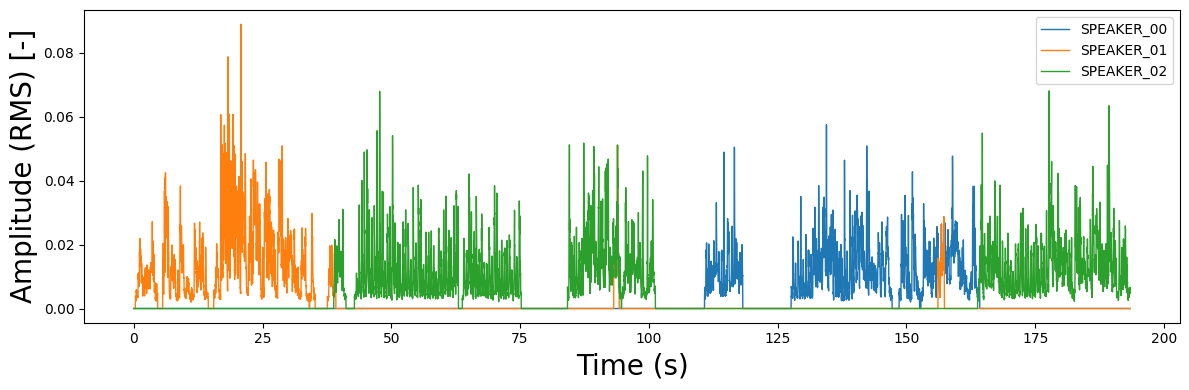

In [15]:
# === ブロック7: 時系列グラフ（話者別RMS） ============================
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
from collections import defaultdict

y_plot, sr_plot = sf.read(wav_for_diar, always_2d=False)
if y_plot.ndim > 1: y_plot = y_plot.mean(axis=1)

hop = int(0.01 * sr_plot)
win = int(0.032 * sr_plot)
num = max(1, 1 + (len(y_plot) - win) // hop)
pad = max(0, win + (num - 1) * hop - len(y_plot))
if pad > 0: y_plot = np.concatenate([y_plot, np.zeros(pad)], axis=0)

rms = np.array([np.sqrt(np.mean(y_plot[i*hop:i*hop+win]**2)) for i in range(num)])
times = (np.arange(num) * hop + win/2) / sr_plot

buckets = defaultdict(list)
for spk, s, e in segments_padded:
    buckets[spk].append((s, e))

plt.figure(figsize=(12, 4))
for spk, spans in sorted(buckets.items()):
    arr = np.zeros_like(rms)
    for s, e in spans:
        mask = (times >= s) & (times < e)
        arr[mask] = rms[mask]
    plt.plot(times, arr, label=spk, linewidth=1.0)



plt.xlabel("Time (s)", fontsize=20)
plt.ylabel("Amplitude (RMS) [-]",fontsize=20)

plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# === ブロック8: 話者別の断片を連結（SR不一致を自動リサンプリング） =====
import numpy as np
import soundfile as sf
from pathlib import Path
from scipy.signal import resample_poly

print("各話者の音声ファイルを連結します...")
concat_dir = OUTDIR / "_concat"; concat_dir.mkdir(exist_ok=True)
speaker_dirs = sorted([d for d in OUTDIR.iterdir() if d.is_dir() and d.name.startswith('raw_spk_')]) ## ここを変更！

TARGET_SR = 16000  # Whisper想定の16kHzに統一

def to_mono(x):
    return x.mean(axis=1) if x.ndim > 1 else x

def resample_if_needed(x, sr, target_sr):
    if sr == target_sr:
        return x
    # polyphase resample: up=target_sr, down=sr
    y = resample_poly(x.astype(np.float32), up=target_sr, down=sr)
    return y

for spk_dir in speaker_dirs:
    speaker_name = spk_dir.name
    wav_files = sorted(list(spk_dir.glob("*.wav")))
    if not wav_files:
        print(f"{speaker_name}: no wavs, skip"); continue

    segs = []
    total_len = 0
    for p in wav_files:
        y_seg, sr = sf.read(p, always_2d=False)
        y_seg = to_mono(y_seg).astype(np.float32)
        y_seg = resample_if_needed(y_seg, sr, TARGET_SR)
        if y_seg.size == 0:
            continue
        segs.append(y_seg)
        total_len += len(y_seg)

    if not segs:
        print(f"{speaker_name}: no valid audio after resample, skip"); continue

    concatenated = np.concatenate(segs)

    mx = np.max(np.abs(concatenated))
    if mx > 1.0:
        concatenated = (concatenated / mx) * 0.999

    out = concat_dir / f"{speaker_name}_raw_concatenated.wav"
    sf.write(out.as_posix(), concatenated.astype(np.float32), TARGET_SR)
    dur = len(concatenated) / TARGET_SR
    print(f"  -> {speaker_name}: {len(wav_files)} files -> {out.name} ({dur:.2f}s @ {TARGET_SR} Hz)")
print("done.")


各話者の音声ファイルを連結します...
done.


### 生波形と加工波形の比較

In [ ]:
# -*- coding: utf-8 -*-
# LTAS と差分を描画（フォントサイズ明示版）

W_RAW  = "/root/MedWhisper/20241018/右後_2回目_川村先生.wav"
W_PROC = "/root/MedWhisper/_work/asr右後ろ2回目川村先生__work.wav"

import numpy as np
import librosa
import matplotlib.pyplot as plt
from pathlib import Path

# --- font sizes ---
TITLE_SIZE = 18
LABEL_SIZE = 16
TICK_SIZE  = 14
LEGEND_SIZE = 14

def load_mono(path, sr=16000):
    y, sr_out = librosa.load(path, sr=sr, mono=True)
    return y.astype(np.float32), sr_out

# def ltas_db(y, sr, n_fft=4096, hop=1024):
#     S = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop))
#     mag_mean = S.mean(axis=1)
#     f = librosa.fft_frequencies(sr=sr, n_fft=n_fft)
#     db = 20.0 * np.log10(mag_mean + 1e-12)
#     return f, db

def ltas_db(y, sr, n_fft=4096, hop=1024):
    S = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop))**2  # power
    P = S.mean(axis=1)                                           # 平均パワー
    f = librosa.fft_frequencies(sr=sr, n_fft=n_fft)
    return f, 10*np.log10(P + 1e-12)


raw, sr = load_mono(W_RAW, sr=16000)
proc, _ = load_mono(W_PROC, sr=sr)
N = min(len(raw), len(proc))
raw = raw[:N]; proc = proc[:N]

f_raw,  d_raw  = ltas_db(raw,  sr, n_fft=4096, hop=1024)
f_proc, d_proc = ltas_db(proc, sr, n_fft=4096, hop=1024)
d_raw_i = np.interp(f_proc, f_raw, d_raw)
d_diff  = d_proc - d_raw_i

plt.figure(figsize=(14, 4.5))

# 左：LTAS
ax1 = plt.subplot(1, 2, 1)
ax1.semilogx(f_proc, d_raw_i,  label="raw",       linewidth=1.2,color = "blue")
ax1.semilogx(f_proc, d_proc,   label="processed", linewidth=1.2,color="red")
ax1.set_xlim(40, 8000)
ax1.set_xlabel("Frequency (Hz)", fontsize=LABEL_SIZE)
ax1.set_ylabel("dB", fontsize=LABEL_SIZE)
# ax1.set_title("LTAS", fontsize=TITLE_SIZE)
ax1.grid(True, which="both", alpha=0.3)
ax1.legend(fontsize=LEGEND_SIZE)
ax1.tick_params(axis='both', which='both', labelsize=TICK_SIZE)

# 右：ΔLTAS
# 右：ΔLTAS
ax2 = plt.subplot(1, 2, 2)
ax2.semilogx(f_proc, d_diff, linewidth=1.5, color="green")
ax2.set_xlim(40, 8000)
ax2.set_ylim(-60, 10)
ax2.set_xlabel("Frequency (Hz)", fontsize=LABEL_SIZE)
ax2.set_ylabel("ΔdB (proc - raw)", fontsize=LABEL_SIZE)
ax2.grid(True, which="both", alpha=0.3)
ax2.tick_params(axis='both', which='both', labelsize=TICK_SIZE)

# ★ 差分の基準線（y=0）を太く表示
ax2.axhline(0, linewidth=2.5, linestyle='-', color='black', alpha=0.9, zorder=0)

plt.tight_layout()

out_path = Path("./outputs/diarization/cmp_ltas_only.png")
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, dpi=150)
plt.show()
